### 0. Import packages

In [1]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist



### 1. Download PDB and metada of MHC-epitope structures

In [2]:
import requests

# List of PDB IDs
pdb_ids = """
1HSB,1SYV,1YDP,1ZVS,3HG1,3KPN,3KPO,3KYN,3KYO,3O4L,3OX8,3OXR,3OXS,3TO2,3VFM,3VFN,3VFO,
3VFP,3VFR,3VFS,3VFT,3VFU,3VFV,3VFW,4GKN,4HX1,4JRX,4JRY,4PRA,4PRB,4PRD,4PRE,4PRH,4PRI,
4PRP,5DEG,5NQ1,5NQ3,5VVP,5VWD,5VWF,6BXQ,6GGM,6GH1,6GH4,6GL1,6ID4,6IEX,6J2E,6K7T,6MTL,
6O4Y,6O4Z,6O51,6O53,6P2S,6P64,6TDO,6TDP,6TDQ,6TDR,6TDS,6TMO,6TRN,6TRO,6UJO,6UJQ,6UK2,
6UK4,6UZM,6UZN,6UZO,6UZP,6UZQ,6UZS,6V2O,6VB0,6VB1,6VB2,6VB3,6VB4,6VB5,6VB6,6VB7,6VIU,
6VPZ,6VQ2,6VQD,6VQE,6VQO,6VQY,6VQZ,6VR1,6VR5,6VRM,6VRN,6W51,6XQA,6Y26,6Y28,6Y2A,6Z9V,
6Z9W,6Z9X,7BBG,7CIQ,7CIR,7CIS,7DUU,7DYN,7DZM,7DZN,7EDO,7EJL,7EJM,7EJN,7EU2,7F4W,7JYU,
7JYV,7JYW,7JYX,7K80,7K81,7KGO,7KGP,7KGQ,7KGR,7KGS,7KGT,7LG2,7LG3,7MJ6,7MJ7,7MJ8,7MJ9,
7MKB,7N6D,7N6E,7NMD,7NME,7NMF,7NMG,7OW3,7OW4,7OW5,7OW6,7P3D,7P3E,7PB2,7PBC,7PBE,7PDW,
7Q98,7Q99,7Q9A,7Q9B,7QPJ,7R7V,7R7W,7R7X,7R7Y,7R80,7RE7,7SA2,7SIF,7SIG,7SIH,7SU9,7T0L,
7T5M,7WKJ,7WT3,7WT4,7WT5,7WZZ,7X00,7XF3,7YG3,7ZUC,8CX4,8E13,8E8I,8EC5,8EK5,8EMF,8EMG,
8EMI,8EMJ,8EMK,8EN8,8ENH,8EO8,8ES8,8ES9,8FJA,8FJB,8GOM,8GON,8GVB,8GVG,8GVI,8HN4,8ISN,
8RJ5,8RJH,8RJI,8RNG,8RNH,8ROO,8ROP,8RYN,8RYQ,8SBK,8SBL,8T6M,8V4Z,8WUL,8YIV,8YZR,8YZW,
8YZZ,8Z06,8Z07,8Z08,8ZV9,9BL5,9BL6,9BL9,9BLA,9C96,9GV6,9GV7,9L47,9L48,9L49,9L4A
""".replace("\n", "").split(",")

# Output directory
output_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"
os.makedirs(output_dir, exist_ok=True)

# Download loop
for pdb_id in pdb_ids:
    pdb_id = pdb_id.strip().lower()
    output_file = os.path.join(output_dir, f"{pdb_id}.pdb")
    
    if os.path.exists(output_file):
        # print(f"⏭️  Skipping {pdb_id.upper()} (already exists)")
        continue

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    response = requests.get(url)
    if response.status_code == 200:
        with open(output_file, "w") as f:
            f.write(response.text)
        print(f"✅ Downloaded {pdb_id.upper()}")
    else:
        print(f"❌ Failed to download {pdb_id.upper()}")

print("🏁 Finished downloading all PDBs.")


❌ Failed to download 7PBC
❌ Failed to download 7PDW
❌ Failed to download 7Q9B
❌ Failed to download 8V4Z
🏁 Finished downloading all PDBs.


In [3]:
def grab_hla(title: str) -> Optional[str]:   # <- use Optional[str] instead of str | None
    """
    Return the first HLA allele in *title* or None.
    Handles:  HLA-A*02:01,  HLA-A02:01,  HLA-A*0201,  HLA-A0201
    """
    patterns = [
        r'(HLA-[A-Z]\*\d{2}:\d{2})',   # HLA-A*02:01
        r'(HLA-[A-Z]\d{2}:\d{2})',     # HLA-A02:01
        r'([A-Z]\*\d{4})',         # HLA-A*0201
        r'(-[A-Z]\*\d{2}:\d{2})'  ,
        r'([A-Z]\d{2}\d{2})'  ,
        r'([A-Z]\*\d{2}:\d{2})' ,
        r'(-[A-Z]\d{1}:\d{2})'  ,
        r'(-[A-Z]\d{1})'   ,
        r'(-[A-Z]\d{2})'            # HLA-A0201
    ]
    for p in patterns:
        m = re.search(p, title, flags=re.IGNORECASE)
        if m:
            return m.group(1).upper()
    return None
    
# Prepare list for metadata
meta_list = []

def get_metadata():
    for pdb in pdb_ids:
        pdb = pdb.strip().lower()
        url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb}"
        try:
            r = requests.get(url)
            if r.status_code != 200:
                raise ValueError(f"Status {r.status_code}")
            data = r.json()
            
            meta = {
                "pdb_id": pdb.upper(),
                "title": data.get("struct", {}).get("title", ""),
                "method": data.get("exptl", [{}])[0].get("method", ""),
                "resolution": data.get("rcsb_entry_info", {}).get("resolution_combined", [None])[0],
                "release_date": data.get("rcsb_accession_info", {}).get("initial_release_date", ""),
                "revision_date": data.get("rcsb_accession_info", {}).get("revision_date", "")
            }
            meta_list.append(meta)
        except Exception as e:
            meta_list.append({
                "pdb_id": pdb.upper(),
                "title": None, "method": None,
                "resolution": None,
                "release_date": None,
                "revision_date": None
            })

    df_meta = pd.DataFrame(meta_list)
    # ------------------------------------------------------------------
    # Apply to your DataFrame
    # ------------------------------------------------------------------
    df_meta_cp        = df_meta.copy()
    df_meta_cp['HLA'] = df_meta_cp['title'].apply(grab_hla)

    # Rows where an allele was detected
    df_hla = df_meta_cp[df_meta_cp['HLA'].notna()][['pdb_id', 'HLA']]

    # If you still need the original metadata columns:
    df_hla = df_hla.merge(df_meta, on='pdb_id', how='right')
    df_hla[~(df_hla['HLA'].notna()) ]['title'].str.split('HLA', expand = True)[1].unique()
    df_hla['hla_allele'] = df_hla['HLA'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')

    return df_meta_cp

# df_meta = 
df_meta = pd.read_csv('../data/metadata.csv')
df_meta.head()

,pdb_id,title,method,resolution,release_date,revision_date
0,1HSB,DIFFERENT LENGTH PEPTIDES BIND TO HLA-AW68 SIM...,X-RAY DIFFRACTION,1.9,1993-10-31T00:00:00+0000,2024-10-30T00:00:00+0000
1,1SYV,HLA-B*4405 complexed to the dominant self liga...,X-RAY DIFFRACTION,1.7,2004-10-19T00:00:00+0000,2024-11-13T00:00:00+0000
2,1YDP,1.9A crystal structure of HLA-G,X-RAY DIFFRACTION,1.9,2005-03-08T00:00:00+0000,2024-10-23T00:00:00+0000
3,1ZVS,Crystal structure of the first class MHC mamu ...,X-RAY DIFFRACTION,2.8,2006-06-13T00:00:00+0000,2024-11-20T00:00:00+0000
4,3HG1,Germline-governed recognition of a cancer epit...,X-RAY DIFFRACTION,3.0,2009-07-28T00:00:00+0000,2024-11-27T00:00:00+0000


In [4]:
contacts = pd.read_csv("../data/mhc_epitope_contacts_15052025.csv.gz",compression='gzip')
contacts = contacts.drop_duplicates()

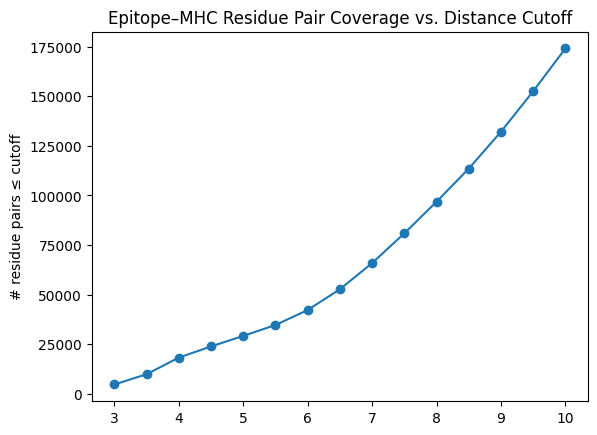

In [5]:
res_contacts = (contacts.groupby(["pdb_id","ep_chain","ep_resnum",
                                  "mhc_chain","mhc_resnum"])
                         ["min_distance"].min()
                         .reset_index())

cutoffs = np.arange(3, 10.5, 0.5)
cov = {c: (res_contacts.min_distance <= c).sum() for c in cutoffs}
cov_df = pd.Series(cov).sort_index()
cov_df.plot(marker="o")
plt.ylabel("# residue pairs ≤ cutoff")
plt.title("Epitope–MHC Residue Pair Coverage vs. Distance Cutoff")
plt.show()

In [6]:
for i in np.arange(1, 11, 0.5):
# percentage of residue pairs ≤ 3 Å
    pct3  = (res_contacts.min_distance <= i).mean() * 100
    
    print(f"≤{i} Å : {pct3:5.2f}%")

≤1.0 Å :  0.00%
≤1.5 Å :  0.00%
≤2.0 Å :  0.00%
≤2.5 Å :  0.15%
≤3.0 Å :  2.68%
≤3.5 Å :  5.67%
≤4.0 Å : 10.47%
≤4.5 Å : 13.70%
≤5.0 Å : 16.75%
≤5.5 Å : 19.91%
≤6.0 Å : 24.25%
≤6.5 Å : 30.26%
≤7.0 Å : 37.85%
≤7.5 Å : 46.45%
≤8.0 Å : 55.61%
≤8.5 Å : 65.19%
≤9.0 Å : 75.88%
≤9.5 Å : 87.60%
≤10.0 Å : 100.00%
≤10.5 Å : 100.00%


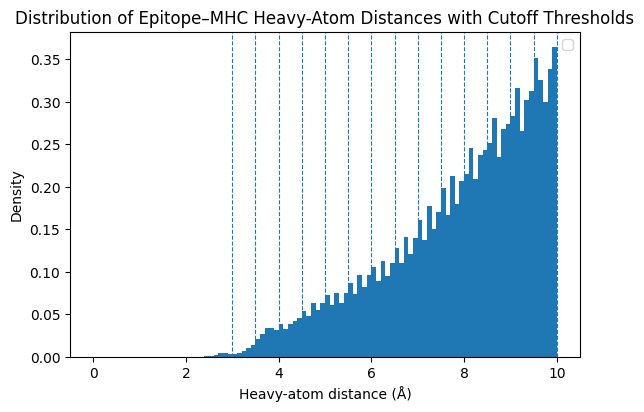

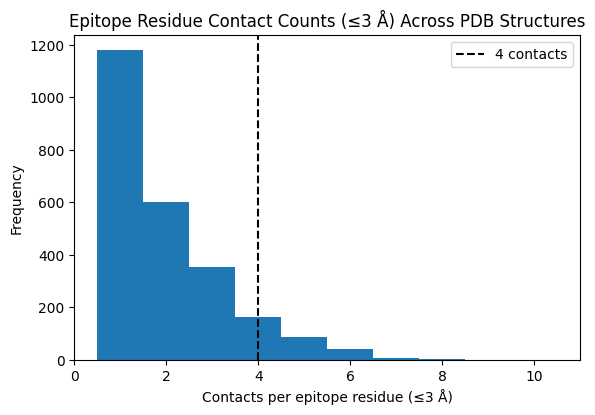

In [7]:
cov = {c: (contacts[contacts.min_distance<=c]
           .drop_duplicates(["pdb_id","ep_chain","ep_resnum"]).shape[0])
       for c in cutoffs}

plt.figure(figsize=(6,4))
plt.hist(contacts["min_distance"], bins=np.arange(0, max(cutoffs)+0.1, 0.1),
         density=True)
for c in cutoffs:
    plt.axvline(c, ls="--", lw=0.8, label=f"{c} Å")
plt.xlabel("Heavy-atom distance (Å)")
plt.ylabel("Density"); plt.legend([]); plt.tight_layout()
plt.title("Distribution of Epitope–MHC Heavy-Atom Distances with Cutoff Thresholds")

plt.show()
# %% 9 Contact-count distribution  (≤3 Å as example)
counts = (contacts[contacts.min_distance<=3]
          .groupby(["pdb_id","ep_chain","ep_resnum"]).size())
plt.figure(figsize=(6,4))
plt.hist(counts, bins=np.arange(1, counts.max()+2)-0.5, align="mid")
plt.axvline(4, ls="--", color="k", label="4 contacts")
plt.xlabel("Contacts per epitope residue (≤3 Å)")
plt.ylabel("Frequency"); plt.legend(); plt.tight_layout()
plt.title("Epitope Residue Contact Counts (≤3 Å) Across PDB Structures")

plt.show()

In [8]:
d = contacts["min_distance"].to_numpy()

# thresholds every 0.5 Å
thr = np.arange(0.0, 10.5, 0.5)
cov = np.array([(d <= t).mean() for t in thr])

# increments from one 0.5 Å step to the next
inc = np.diff(cov)                         # fraction
inc_pct = 100 * inc  

boot_cov5 = []
for _ in range(100):
    res = np.random.choice(d, size=d.size, replace=True)
    boot_cov5.append((res <= 5).mean())
ci5_low, ci5_high = np.percentile(boot_cov5, [2.5, 97.5])
print(f"95 % CI for ≤5 Å: {ci5_low*100:.2f}–{ci5_high*100:.2f} %")

95 % CI for ≤5 Å: 6.88–6.93 %


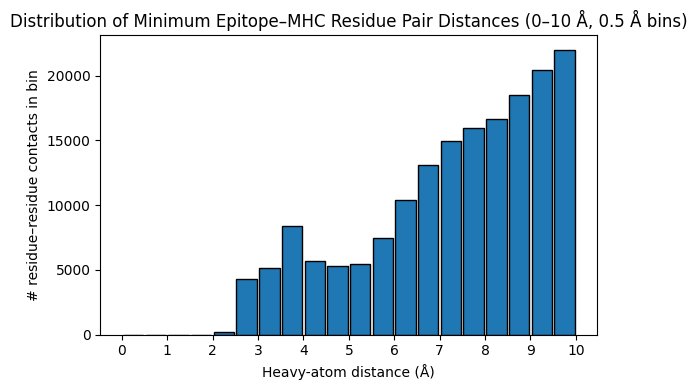

In [9]:
# %% Collapse raw atom-atom table to one distance per residue pair  (skip if res_contacts already exists)
res_contacts = (
    contacts.groupby(["pdb_id","ep_chain","ep_resnum",
                      "mhc_chain","mhc_resnum"])["min_distance"]
            .min()
            .reset_index()
)

bin_edges = np.arange(0, 10.5, 0.5)          # 0–10 Å, half-Å bins
hist, _ = np.histogram(res_contacts["min_distance"], bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(6,4))
plt.bar(bin_centers, hist, width=0.45, align="center", edgecolor="black")
plt.xlabel("Heavy-atom distance (Å)")
plt.ylabel("# residue–residue contacts in bin")
plt.xticks(np.arange(0, 10.5, 1))
plt.title("Distribution of Minimum Epitope–MHC Residue Pair Distances (0–10 Å, 0.5 Å bins)")

plt.tight_layout()
plt.show()

In [10]:
def get_chain_summary():
    # Local directory containing the PDBs
    pdb_dir = "../pdb_files/"

    # Get list of all PDB files
    pdb_files = [f for f in os.listdir(pdb_dir) if f.endswith(".pdb")]

    parser = PDBParser(QUIET=True)
    results = []

    for pdb_file in pdb_files:
        pdb_id = pdb_file.replace(".pdb", "").upper()
        path = os.path.join(pdb_dir, pdb_file)

        try:
            structure = parser.get_structure(pdb_id, path)[0]  # Use first model
        except Exception as e:
            print(f"❌ Skipping {pdb_id} due to error: {e}")
            continue

        for chain in structure.get_chains():
            residues = [res for res in chain if is_aa(res)]
            results.append({
                "pdb_id": pdb_id,
                "chain_id": chain.id,
                "num_residues": len(residues),
                "residues_preview": "-".join(res.resname for res in residues[:5]) + ("..." if len(residues) > 5 else "")
            })
    df = pd.DataFrame(results)
    df.to_csv("pdb_chain_summary.csv", index=False)
    print("✅ Finished. Saved chain info to pdb_chain_summary.csv")
    return df

pdb_chain_summary = pd.read_csv("../data/pdb_chain_summary.csv")
pdb_chain_summary.head()

,pdb_id,chain_id,num_residues,residues_preview
0,6UZN,A,276,GLY-SER-HIS-SER-MET...
1,6UZN,B,100,MET-ILE-GLN-ARG-THR...
2,6UZN,C,9,THR-VAL-ARG-ALA-SER...
3,8SBK,A,275,GLY-SER-HIS-SER-MET...
4,8SBK,B,100,MET-ILE-GLN-ARG-THR...


In [11]:
def get_contacts_high_res():
    pdb_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"
    cutoff = 5.0  # Å

    parser = PDBParser(QUIET=True)
    all_contacts = []

    for pdb_file in os.listdir(pdb_dir):
        if not pdb_file.endswith(".pdb"):
            continue

        pdb_id = pdb_file.replace(".pdb", "").upper()
        pdb_path = os.path.join(pdb_dir, pdb_file)

        try:
            structure = parser.get_structure(pdb_id, pdb_path)[0]  # first model
            chains = list(structure.get_chains())

            # Chain lengths for auto-classification
            chain_lens = {ch.id: len([res for res in ch if res.id[0] == " "]) for ch in chains}
            epitopes = [cid for cid, l in chain_lens.items() if 7 <= l <= 15]
            mhcs     = [cid for cid, l in chain_lens.items() if 150 <= l <= 300]

            for epi_id in epitopes:
                for mhc_id in mhcs:
                    atoms_epi = [a for a in structure[epi_id].get_atoms() if a.element != "H"]
                    atoms_mhc = [a for a in structure[mhc_id].get_atoms() if a.element != "H"]
                    ns = NeighborSearch(atoms_epi + atoms_mhc)

                    for atom in atoms_epi:
                        for neighbor in ns.search(atom.coord, cutoff):
                            if neighbor in atoms_mhc:
                                res_epi = atom.get_parent()
                                res_mhc = neighbor.get_parent()
                                coords_epi = np.array([a.coord for a in res_epi if a.element != "H"])
                                coords_mhc = np.array([a.coord for a in res_mhc if a.element != "H"])
                                min_dist = cdist(coords_epi, coords_mhc).min()

                                all_contacts.append({
                                    "pdb_id": pdb_id,
                                    "epitope_chain": epi_id,
                                    "epitope_resnum": res_epi.id[1],
                                    "epitope_resname": res_epi.resname,
                                    "mhc_chain": mhc_id,
                                    "mhc_resnum": res_mhc.id[1],
                                    "mhc_resname": res_mhc.resname,
                                    "min_distance": round(min_dist, 2)
                                })

        except Exception as e:
            print(f"❌ {pdb_id} skipped: {e}")
            continue

    # Create and save the final dataframe
    df = pd.DataFrame(all_contacts)
    df.to_csv("mhc_epitope_contacts.csv", index=False)
    print("✅ Saved contact table as mhc_epitope_contacts.csv")
    return df 

mhc_epitope_contacts = pd.read_csv("../data/mhc_epitope_contacts.csv")
interactions = mhc_epitope_contacts.drop_duplicates().reset_index(drop=True)
interactions.head()

,pdb_id,epitope_chain,epitope_resnum,epitope_resname,mhc_chain,mhc_resnum,mhc_resname,min_distance
0,6UZN,C,1,THR,A,167,TRP,3.44
1,6UZN,C,1,THR,A,5,MET,4.22
2,6UZN,C,1,THR,A,171,TYR,2.57
3,6UZN,C,1,THR,A,33,PHE,4.86
4,6UZN,C,1,THR,A,59,TYR,3.72


| Name           | What it captures                                                                                                      | Threshold (after ≤ 5 Å cutoff) | hotspot (copy-ready)                                                                                  |
|----------------|-----------------------------------------------------------------------------------------------------------------------|---------------------------------|-------------------------------------------------------------------------------------------------------|
| **core_hotspot**     | Only the strongest binding hot-spots—absolute core you almost never want to mutate.                                   | ≥ 4 distinct protein contacts  | `"A66,A70,A159"`                                                                                     |
| **high_contact**     | Core + secondary hubs. Good default when you want to preserve the bulk of the binding energy.                       | ≥ 3 contacts                    | `"A66,A70,A73,A77,A97,A147,A159"`                                                                    |
| **medium_contact**   | Moderately important residues; nice to keep fixed if you want a very native-like interface.                         | = 2 contacts                     | `"A7,A63,A99,A116,A143,A146,A155,A156"`                                                              |
| **low_contact**      | Peripheral/edge residues; usually safe to let RFdiffusion mutate for better packing/solubility.                     | = 1 contact                      | `"A5,A9,A33,A45,A59,A67,A69,A76,A80,A81,A84,A95,A114,A123,A124,A142,A152,A160,A163,A167,A171"`       |
| **combo_high_low**   | Lock the high-energy core while leaving medium residues flexible (high + low combined).                             | see above                        | `"A5,A9,A33,A45,A59,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A114,A123,A124,A142,A147,A152,A159"` |
| **all_contacts**     | Every chain-A residue that has ≥ 1 heavy-atom within 5 Å of chain C (36 total). Use to freeze the entire native interface. | ≥ 1 contact                      | `"A5,A7,A9,A33,A45,A59,A63,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A99,A114,A116,A123,A124,A142,A143,A146,A147,A152,A155,A156,A159,A160,A163,A167,A171"` |
| **user_hotspot**     | Your original 9-residue list.                                                                                       | (user-defined)                   | `"A7,A9,A59,A63,A66,A70,A99,A159,A167"`                                                              |


In [12]:
# 1. Count how many distinct epitope residues contact each MHC residue
contact_counts = interactions.groupby(['mhc_chain', 'mhc_resnum'])['epitope_resnum'].nunique().reset_index()
contact_counts = contact_counts.rename(columns={'epitope_resnum': 'contact_count'})

# 2. Merge back into original interaction DataFrame
interactions = interactions.merge(contact_counts, on=['mhc_chain', 'mhc_resnum'], how='left')

# 3. Assign importance tier based on contact count
interactions["importance"] = interactions["contact_count"].map(
    lambda x: "core_hotspot" if x >= 4 else
              "high_contact" if x == 3 else
              "medium_contact" if x == 2 else
              "low_contact"
)

In [13]:
interactions_sub = interactions[(interactions['mhc_resnum'] < 400) & (interactions['epitope_resnum'] < 14)]

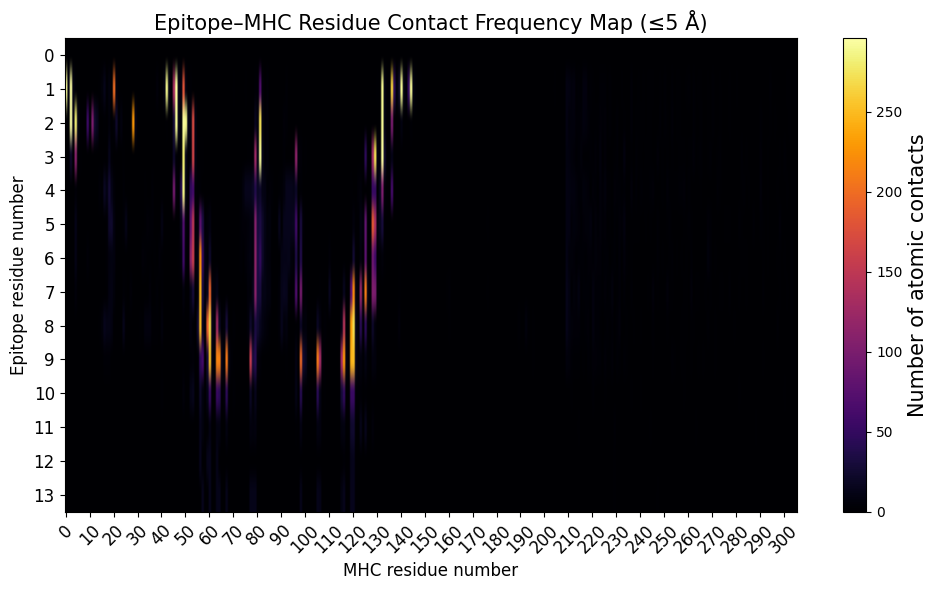

In [14]:
interactions_sub
contact_matrix = (
    pd.crosstab(interactions_sub["mhc_resnum"], interactions_sub["epitope_resnum"])
    .sort_index(axis=0)  # sort MHC residues
    .sort_index(axis=1)  # sort epitope residues
).T

# 2. Plot heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(contact_matrix, aspect="auto", cmap="inferno")

# Axis labels & ticks
ax.set_ylabel("Epitope residue number", size = 12)
ax.set_xlabel("MHC residue number", size = 12)
ax.set_title("MHC–Epitope contact counts", size = 15)

# Tick positions & labels
ax.set_xticks(np.arange(0, 310, 10))
ax.set_xticklabels(np.arange(0, 310, 10), size = 12, rotation =45)
ax.set_yticks(range(contact_matrix.shape[0]))
ax.set_yticklabels(contact_matrix.index, size = 12)

# Colorbar to indicate count intensity
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of atomic contacts", size = 15) #, rotation = 0)
ax.set_title("Epitope–MHC Residue Contact Frequency Map (≤5 Å)", size=15)


plt.tight_layout()

In [15]:
np.arange(0, 389, 10)

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250,
       260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380])

In [16]:
core_counts = (
    interactions[(interactions['importance'] == 'core_hotspot') & 
                 (interactions['min_distance'] < 3)]
    .groupby('pdb_id')['mhc_resnum']
    .nunique()
    .reset_index(name='n_core_hotspot_residues')
    .sort_values(by='n_core_hotspot_residues', ascending=False)
)


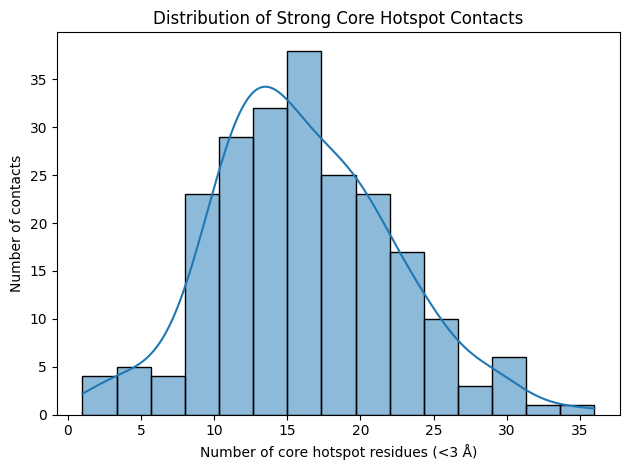

In [17]:
sns.histplot(core_counts['n_core_hotspot_residues'], bins=15, kde=True)
plt.xlabel('Number of core hotspot residues (<3 Å)')
plt.ylabel('Number of contacts')
plt.title('Distribution of Strong Core Hotspot Contacts')
plt.tight_layout()
plt.show()


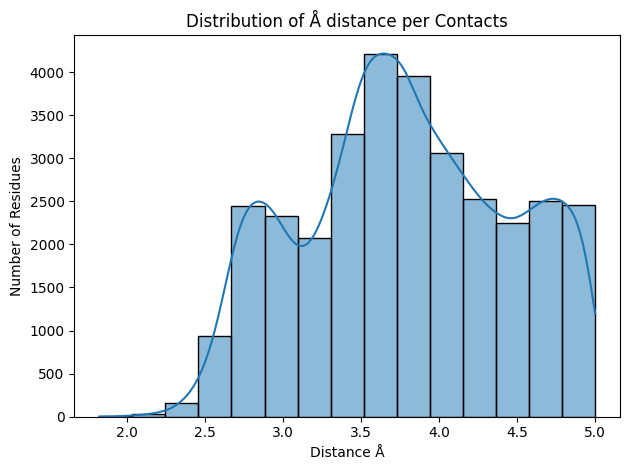

In [18]:
sns.histplot(interactions['min_distance'], bins=15, kde=True)
plt.xlabel('Distance Å')
plt.ylabel('Number of Residues')
plt.title('Distribution of Å distance per Contacts')
plt.tight_layout()
plt.show()


#### Create the SLURM jobs

In [19]:
# Count chains per PDB
chain_counts = pdb_chain_summary.groupby('pdb_id').size().reset_index(name='num_chains')

# Filter to PDBs that have exactly 3 chains
three_chain_pdbs = chain_counts[chain_counts['num_chains'] == 3].sort_values(by='num_chains', ascending=False)


# Filter the full chain summary to only 3-chain PDBs
filtered_summary = pdb_chain_summary[pdb_chain_summary['pdb_id'].isin(three_chain_pdbs['pdb_id'])]

# 1) Build the job parameters DataFrame
job_params = []

# Only include PDBs with exactly 3 chains
chain_counts = filtered_summary.groupby('pdb_id').size()
three_chain_pdbs = chain_counts[chain_counts == 3].index.tolist()


def create_jobs():
    for pdb_id in three_chain_pdbs:
        chains_df = filtered_summary[filtered_summary['pdb_id'] == pdb_id]
        chains = ",".join(chains_df['chain_id'].tolist())
        
        # Determine epitope chain: the one with smallest num_residues
        ep_chain = chains_df.loc[chains_df['num_residues'].idxmin(), 'chain_id']
        
        # Collect hotspot residues (core + high + medium)
        inter_df = interactions[
            (interactions['pdb_id'] == pdb_id) &
            (interactions['epitope_chain'] == ep_chain) &
            (interactions['importance'].isin(['core_hotspot','high_contact','medium_contact']))
        ]
        hotspots = sorted({f"{row['mhc_chain']}{row['mhc_resnum']}" for _, row in inter_df.iterrows()})

        if len(hotspots) < 5:
            inter_df = interactions[
                (interactions['pdb_id'] == pdb_id) &
                (interactions['epitope_chain'] == ep_chain) &
                (interactions['importance'].isin(['high_contact','medium_contact']))
            ]
        
        job_params.append({
            'pdb_id': pdb_id,
            'chains': chains,
            'epitope_chain': ep_chain,
            'hotspots': ",".join(hotspots)
        })

    df_job_params = pd.DataFrame(job_params)

    # 2) Generate SLURM scripts from df_job_params
    script_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/run_RFDiffusionMHC_epitope.py"
    sh_dir   = Path("/clusterfs/nilah/sergio/RFdifussion/slurm_jobs/EPITOPE_SERIES3")
    log_dir  = Path("/clusterfs/nilah/sergio/RFdifussion/logs/EPITOPE_SERIES2")

    sh_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    iterations_list = [50]
    num_seqs_list   = [32]

    for trial in range(2100, 2300):
        for _, row in df_job_params.iterrows():
            # get chain lengths for contigs construction
            lengths = {
                ch: filtered_summary.query(f"pdb_id=='{row.pdb_id}' & chain_id=='{ch}'").num_residues.item()
                for ch in row.chains.split(",")
            }
            # build contigs string
            parts = []
            for ch, L in lengths.items():

                if ch == row.epitope_chain:
                    
                    LENGTH = np.random.randint(7,13)
                    L = LENGTH

                    parts.append(f"0/{L}")
                else:
                    parts.append(f"{ch}1-{L}/0")
            full_contigs = " ".join(parts)

            for it in iterations_list:
                for ns in num_seqs_list:
                    base = f"{row.pdb_id}_C{row.epitope_chain}{lengths[row.epitope_chain]}_I{it}_NS{ns}_{LENGTH}_{trial}"
                    fname = f"RFD_HP_{base}"
                    sh_path = sh_dir / f"{fname}.sh"
                    cmd = (
                        f"python {script_path} "
                        f"--name {fname} "
                        f"--pdb {row.pdb_id} "
                        f"--contigs \"{full_contigs}\" "
                        f"--hotspots \"{row.hotspots}\" "
                        f"--chains {row.chains} "
                        f"--epitope_chain {row.epitope_chain} "
                        f"--iterations {it} "
                        f"--num_seqs {ns}"
                    )
                    with open(sh_path, "w") as fh:
                        fh.write("#!/bin/bash\n")
                        fh.write("#SBATCH --account=co_nilah\n")
                        fh.write("#SBATCH --partition=savio3_gpu\n") #savio3_gpu savio2_1080ti
                        fh.write("#SBATCH --qos=savio_lowprio\n")
                        fh.write("#SBATCH --cpus-per-task=4\n")
                        fh.write("#SBATCH --gres=gpu:1\n")
                        fh.write("#SBATCH --requeue\n")
                        fh.write("#SBATCH --time=00:57:00\n")
                        fh.write(f"#SBATCH --job-name={fname}\n")
                        fh.write(f"#SBATCH --output={log_dir}/{fname}_%j.out\n")
                        fh.write(f"#SBATCH --error={log_dir}/{fname}_%j.err\n\n")
                        fh.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
                        fh.write("conda activate SE3nv\n\n")
                        fh.write(cmd + "\n")
                    os.chmod(sh_path, 0o755)
                    print(f"✅ Created {sh_path.name}")
        
# create_jobs()